## U-Net based semantic segmentation of cars, roads etc. for Lyft Udacity Challenge.
[[**Dataset**](https://www.kaggle.com/datasets/kumaresanmanickavelu/lyft-udacity-challenge)](http://)

Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2
import glob
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPool2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model

# **Display images and ground truth masks**
The data has 5 sets of 1000 images and corresponding labels.

In [ ]:
def plot_images_and_masks(data_folder):
    subfolders = ['dataA', 'dataB', 'dataC', 'dataD', 'dataE']
    num_images_to_plot = 3

    for subfolder in subfolders:
        image_subfolder_path = os.path.join(data_folder, subfolder, subfolder, 'CameraRGB')
        mask_subfolder_path = os.path.join(data_folder, subfolder, subfolder, 'CameraSeg')

        image_files = os.listdir(image_subfolder_path)
        mask_files = os.listdir(mask_subfolder_path)

        for i in range(num_images_to_plot):
            image_path = os.path.join(image_subfolder_path, image_files[i])
            mask_path = os.path.join(mask_subfolder_path, mask_files[i])

            image = cv2.imread(image_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.title(f'Image {i+1} - Subfolder: {subfolder}')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(mask)  # Display mask in grayscale
            plt.title(f'Mask {i+1} - Subfolder: {subfolder}')
            plt.axis('off')

            plt.show()


In [ ]:
# Step 1: Set up Kaggle API key
import os

# Ensure the Kaggle API key is in the correct location
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Install necessary dependencies if not installed
!pip install kaggle kagglehub --quiet

import kagglehub

# Step 2: Download the dataset using KaggleHub
path = kagglehub.dataset_download("kumaresanmanickavelu/lyft-udacity-challenge")

print("Dataset downloaded to:", path)

# Alternative method using Kaggle API if needed
!kaggle datasets download -d kumaresanmanickavelu/lyft-udacity-challenge --unzip -p /content/dataset


100%|██████████| 5.11G/5.11G [00:48<00:00, 114MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/kumaresanmanickavelu/lyft-udacity-challenge/versions/1
Dataset URL: https://www.kaggle.com/datasets/kumaresanmanickavelu/lyft-udacity-challenge
License(s): CC0-1.0
100% 5.11G/5.11G [01:28<00:00, 87.1MB/s]
100% 5.11G/5.11G [01:28<00:00, 62.2MB/s]


In [ ]:
images_list = []
masks_list = []
def store_imgs_masks(data):
    images_list.append(glob.glob('/content/dataset/'+data+'/'+data+'/CameraRGB/*.png'))
    masks_list.append(glob.glob('/content/dataset/'+data+'/'+data+'/CameraSeg/*.png'))

# storing images and masks in list

In [ ]:
store_imgs_masks('dataA')
store_imgs_masks('dataB')
store_imgs_masks('dataC')
store_imgs_masks('dataD')
store_imgs_masks('dataE')
print(len(images_list))
print(len(masks_list))

5
5


In [ ]:
def get_one_list(list_of_lists):

    one_list = []

    for sublist in list_of_lists:
        one_list.extend(sublist)
    return one_list

In [ ]:
images_list = get_one_list(images_list)
masks_list = get_one_list(masks_list)

In [ ]:
print(images_list[4], '\n')
print(masks_list[4])

['/content/dataset/dataE/dataE/CameraRGB/03_01_138.png', '/content/dataset/dataE/dataE/CameraRGB/05_00_148.png', '/content/dataset/dataE/dataE/CameraRGB/F61-38.png', '/content/dataset/dataE/dataE/CameraRGB/10_00_209.png', '/content/dataset/dataE/dataE/CameraRGB/09_00_019.png', '/content/dataset/dataE/dataE/CameraRGB/02_01_148.png', '/content/dataset/dataE/dataE/CameraRGB/F10-59.png', '/content/dataset/dataE/dataE/CameraRGB/F67-68.png', '/content/dataset/dataE/dataE/CameraRGB/09_00_129.png', '/content/dataset/dataE/dataE/CameraRGB/03_00_088.png', '/content/dataset/dataE/dataE/CameraRGB/08_00_068.png', '/content/dataset/dataE/dataE/CameraRGB/F68-8.png', '/content/dataset/dataE/dataE/CameraRGB/F8-38.png', '/content/dataset/dataE/dataE/CameraRGB/F62-18.png', '/content/dataset/dataE/dataE/CameraRGB/02_02_098.png', '/content/dataset/dataE/dataE/CameraRGB/02_01_149.png', '/content/dataset/dataE/dataE/CameraRGB/03_01_198.png', '/content/dataset/dataE/dataE/CameraRGB/09_00_009.png', '/content/d

# Transforming the lists  to tensors

In [ ]:
#image_list_ds = tf.data.Dataset.list_files(images_list, shuffle=False)
#mask_list_ds = tf.data.Dataset.list_files(masks_list, shuffle=False)

#for path in zip(image_list_ds.take(3), mask_list_ds.take(3)):
    #print(path)
import tensorflow as tf

# Make sure lists are flattened & contain only strings
images_list = [str(p) for p in images_list]
masks_list = [str(p) for p in masks_list]

# Create datasets from lists
image_list_ds = tf.data.Dataset.from_tensor_slices(images_list)
mask_list_ds = tf.data.Dataset.from_tensor_slices(masks_list)

# Zip them together so each image matches its mask
dataset = tf.data.Dataset.zip((image_list_ds, mask_list_ds))

# Check a few samples
for img_path, mask_path in dataset.take(3):
    print("Image:", img_path.numpy().decode('utf-8'))
    print("Mask:", mask_path.numpy().decode('utf-8'))


Image: /content/dataset/dataA/dataA/CameraRGB/F5-90.png
Mask: /content/dataset/dataA/dataA/CameraSeg/F5-90.png
Image: /content/dataset/dataA/dataA/CameraRGB/F6-81.png
Mask: /content/dataset/dataA/dataA/CameraSeg/F6-81.png
Image: /content/dataset/dataA/dataA/CameraRGB/07_00_151.png
Mask: /content/dataset/dataA/dataA/CameraSeg/07_00_151.png


In [ ]:
image_filenames = tf.constant(images_list)
masks_filenames = tf.constant(masks_list)
dataset = tf.data.Dataset.from_tensor_slices((image_filenames, masks_filenames))

for image, mask in dataset.take(1):
    print(image)
    print(mask)

# Preprocessing of images and masks

In [ ]:
def process_path(image_path, mask_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)
    mask = tf.math.reduce_max(mask, axis=-1, keepdims=True)
    return img, mask

def preprocess(image, mask):
    input_image = tf.image.resize(image, (192, 256), method='nearest')
    input_mask = tf.image.resize(mask, (192, 256), method='nearest')

    return input_image, input_mask

image_ds = dataset.map(process_path)
processed_image_ds = image_ds.map(preprocess)

In [ ]:
uniques = set()

for img, mask in image_ds.take(5000):
    uniques.update(np.unique(mask.numpy()))

print("Number of classes: ", uniques)

Number of classes:  {np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12)}


# Building U-Net

In [ ]:
def conv_block(inputs, filters, pool=True):
    x = Conv2D(filters, 3, padding='same')(inputs) #convolution (Downsampling) layer
    x = BatchNormalization()(x) #Batch normalization
    x = Activation('relu')(x) #ReLU (Rectified Linear Unit) Activation Function

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    if pool == True:
        p = MaxPool2D((2,2))(x) #Maxpooling layer
        return x, p # x is filters and p is output feature map obtained after maxpooling
    else:
        return x


def build_unet(shape, num_classes):   # this function is used to create unet architecture using conv_block function
    inputs = Input(shape)

    filters_x = [16,32,48,64,64,48,32,16]
    filters_b = [128]

    # Encoder : Encoder path consist of 4 blocks
    # Encoder path is used to capture context (feature map) of input image in order to do segmentation
    x1, p1 = conv_block(inputs, filters_x[0], pool=True)
    x2, p2 = conv_block(p1, filters_x[1], pool=True)
    x3, p3 = conv_block(p2, filters_x[2], pool=True)
    x4, p4 = conv_block(p3, filters_x[3], pool=True)

    # Bridge
    b1 = conv_block(p4, filters_b[0], pool=False) #Bridge is used to pass context from Encoder layer to Decoder layer

    # Decoder : Decoder path consist of 4 blocks
    # Decoder path is used to reconstruct segmentation image from contracted image obtained from encoder path
    u1 = UpSampling2D((2,2), interpolation='bilinear')(b1) #DeConvolution (upsampling) layer for upsizing image.
    c1 = Concatenate()([u1, x4]) #Concatenation layer - It concatenates current image with corresponding image from encoder path to increase pixel precision.
    x5 = conv_block(c1, filters_x[4], pool=False) #convolution layer with no pooling

    u2 = UpSampling2D((2,2), interpolation='bilinear')(x5)
    c2 = Concatenate()([u2, x3])
    x6 = conv_block(c2, filters_x[5], pool=False)

    u3 = UpSampling2D((2,2), interpolation='bilinear')(x6)
    c3 = Concatenate()([u3, x2])
    x7 = conv_block(c3, filters_x[6], pool=False)

    u4 = UpSampling2D((2,2), interpolation='bilinear')(x7)
    c4 = Concatenate()([u4, x1])
    x8 = conv_block(c4, filters_x[7], pool=False)

    # Output Layer
    output = Conv2D(num_classes, 1, padding='same', activation='softmax')(x8) # Output layer to create segmentation image of same size.
    # 'softmax' activation function is used to classify pixels into different classes

    return Model(inputs, output)

In [ ]:
## Define the resolution of the images and the number of classes

H = 192
W = 256
num_classes = 13
#calling function to build model
unet = build_unet((H, W, 3), num_classes)

# Model summary

In [ ]:
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 256,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 192, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 256,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 256,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 192, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 128,   │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 96, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 128,   │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 96, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 64,    │     13,872 │ max_pooling2d_1[… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64,    │        192 │ conv2d_4[0][0]  

 Total params: 599,565 (2.29 MB)

 Trainable params: 597,773 (2.28 MB)

 Non-trainable params: 1,792 (7.00 KB)

# Compiling models

In [ ]:
unet.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Training models

Total images: 5000
Train: 4000  Val: 1000
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 214s 267ms/step - accuracy: 0.8329 - loss: 0.7228 - val_accuracy: 0.9116 - val_loss: 0.2290 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 77ms/step - accuracy: 0.9314 - loss: 0.1664 - val_accuracy: 0.9384 - val_loss: 0.1340 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.9386 - loss: 0.1309 - val_accuracy: 0.9392 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.9419 - loss: 0.1163 - val_accuracy: 0.9404 - val_loss: 0.1223 - learning_rate: 0.0010
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.9440 - loss: 0.1078 - val_accuracy: 0.9469 - val_loss: 0.1003 - learning_rate: 0.0010
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.9462 - loss: 0.1002 - val_accuracy: 0.9478 - val_loss: 0.0976 - learning_rate: 0.0010
Epoch 7/10
500/500 ━━━━━━━━━━━━━

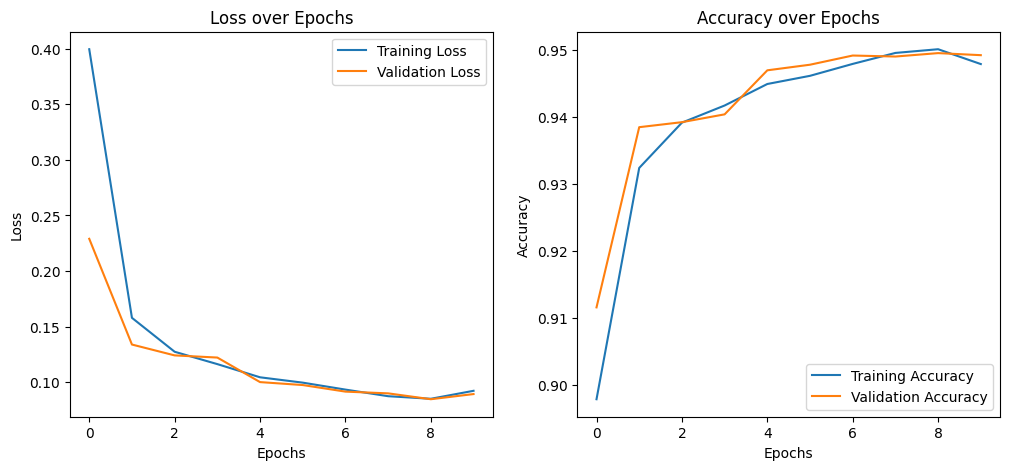

In [ ]:

import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------
# CONFIG
# -------------------------------
EPOCHS = 10            # smaller for testing
BUFFER_SIZE = 1000
BATCH_SIZE = 8         # smaller batch to save memory
IMG_SIZE = (192, 256)  # must match U-Net input size

# -------------------------------
# LOAD & PREPROCESS DATA
# -------------------------------
def load_image_mask(img_path, mask_path):
    # Load image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.convert_image_dtype(mask, tf.uint8)

    # Resize to correct input size
    img = tf.image.resize(img, IMG_SIZE)
    mask = tf.image.resize(mask, IMG_SIZE)

    return img, mask

# Assuming you have `images_list` and `masks_list` as paths
processed_image_ds = tf.data.Dataset.from_tensor_slices((images_list, masks_list))
processed_image_ds = processed_image_ds.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

# -------------------------------
# SPLIT DATASET
# -------------------------------
num_samples = processed_image_ds.reduce(0, lambda x, _: x + 1).numpy()
train_size = int(0.8 * num_samples)
val_size = num_samples - train_size

print("Total images:", num_samples)
print("Train:", train_size, " Val:", val_size)

train_dataset = (processed_image_ds
                 .take(train_size)
                 .cache()
                 .shuffle(BUFFER_SIZE)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

val_dataset = (processed_image_ds
               .skip(train_size)
               .cache()
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

# -------------------------------
# CALLBACKS
# -------------------------------
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    min_lr=1e-6
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# -------------------------------
# COMPILE U-NET
# -------------------------------
# Make sure your U-Net model is defined like this:
# unet = build_unet(input_shape=(192, 256, 3), num_classes=...)
unet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # use binary_crossentropy for 2-class masks
    metrics=['accuracy']
)

# -------------------------------
# TRAINING
# -------------------------------
model_history1 = unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[reduce_lr, early_stop]
)

# -------------------------------
# PLOTTING HISTORY
# -------------------------------
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(model_history1.history['loss'], label='Training Loss')
plt.plot(model_history1.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy (if available)
if 'accuracy' in model_history1.history:
    plt.subplot(1,2,2)
    plt.plot(model_history1.history['accuracy'], label='Training Accuracy')
    plt.plot(model_history1.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

plt.show()






# Models' performance

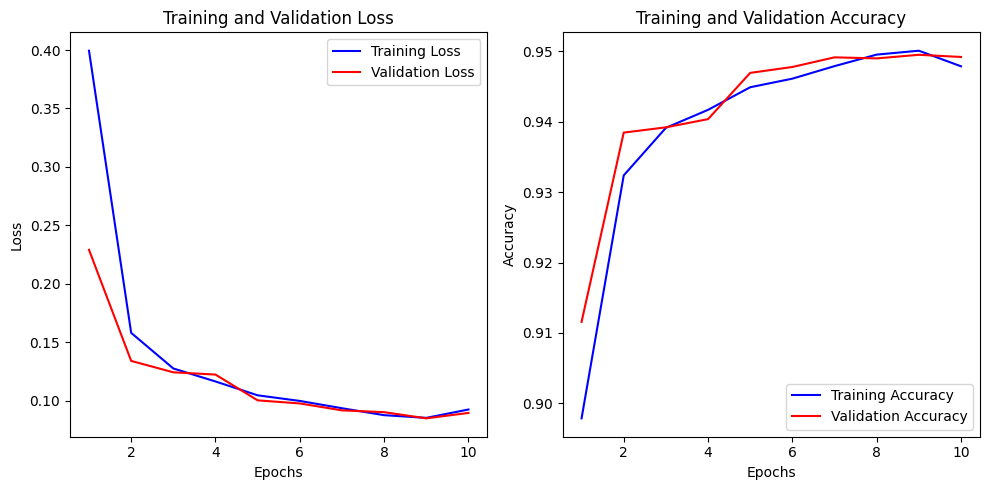

In [ ]:
def plot_loss_and_accuracy(model_history):
    # Get the training and validation loss and accuracy values from the model history
    train_loss = model_history.history['loss']
    val_loss = model_history.history['val_loss']
    train_accuracy = model_history.history['accuracy']
    val_accuracy = model_history.history['val_accuracy']

    epochs = range(1, len(train_loss) + 1)

    # Plot loss
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_loss_and_accuracy(model_history1)

# Prediction

In [ ]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

def display(display_list):
    plt.figure(figsize=(15, 15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

In [ ]:
def show_predictions(unet = unet, dataset=None, num=1):
    """
    Displays the first image of each of the num batches
    """
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = unet.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])
    else:
        display([sample_image, sample_mask,
             create_mask(unet.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


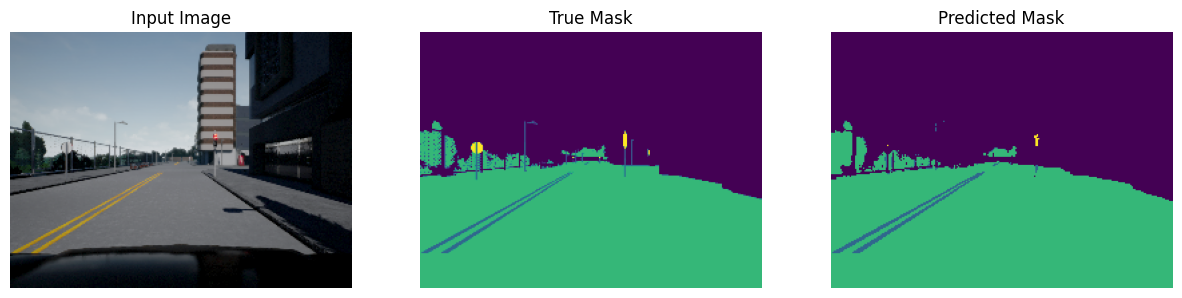

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


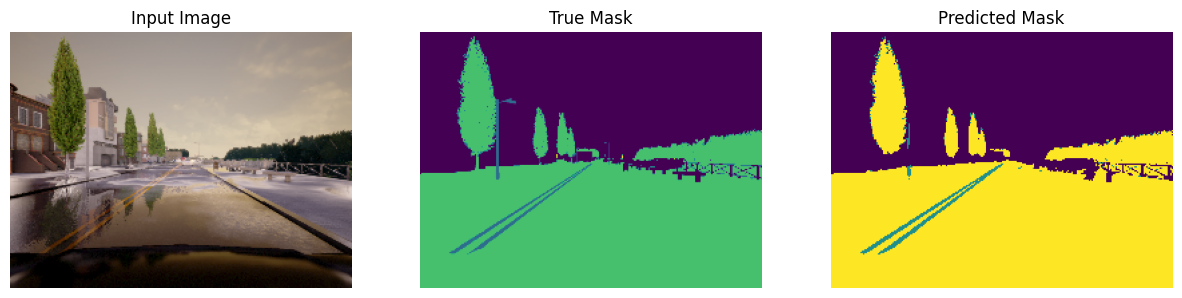

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


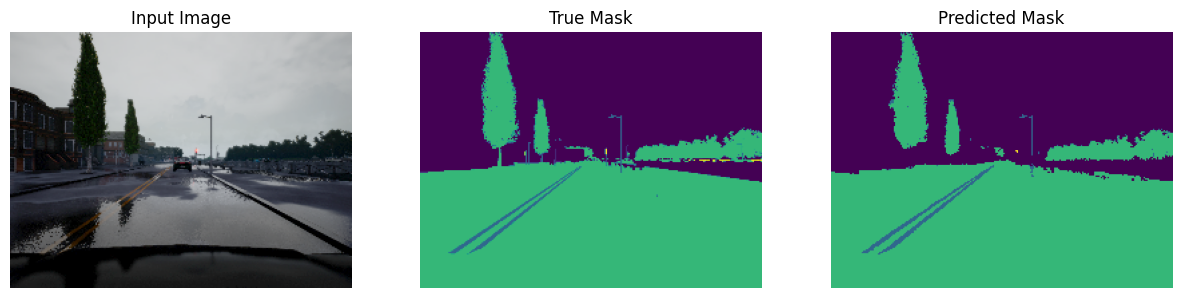

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


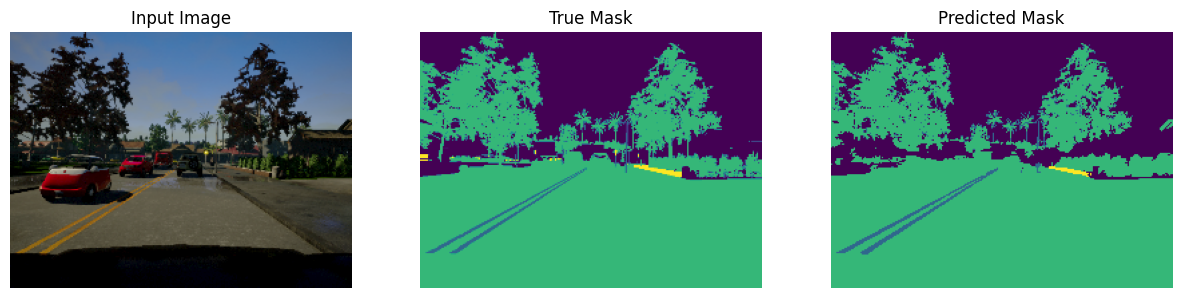

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


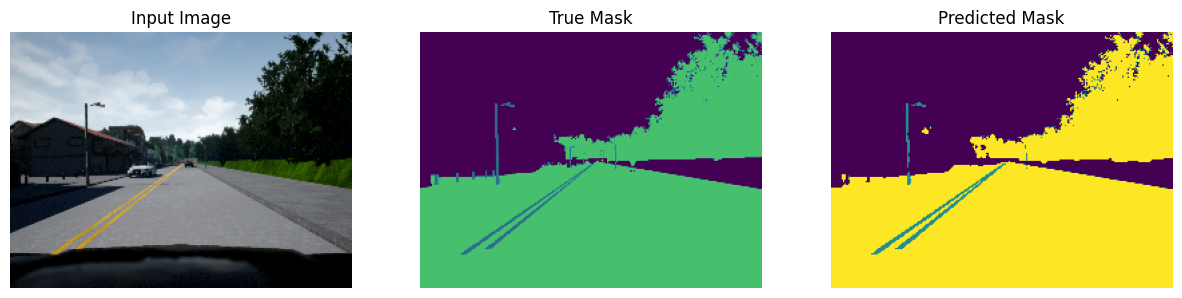

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


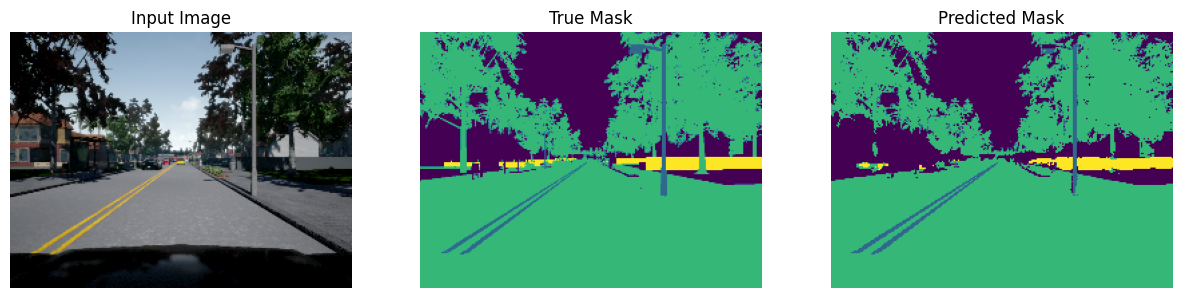

In [ ]:
show_predictions(unet,train_dataset, 6)

# Saving the model

In [ ]:
tf.keras.models.save_model(unet, '/kaggle/working/model.h5')

In [ ]:
# YOLOv8 is part of ultralytics package
!pip install ultralytics  #The ultralytics package has the YOLO class

In [ ]:
# import libraries
import numpy as np
import pandas as pd
from ultralytics import YOLO
import cv2
import PIL
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
import os
import pathlib

In [ ]:
# create model using pretrained yolov8
model = YOLO("yolov8m.pt")

Saving img.jpg to img (1).jpg
Uploaded file path: /content/img (1).jpg

image 1/1 /content/img (1).jpg: 416x640 11 cars, 1 bus, 3 trucks, 27.1ms
Speed: 2.8ms preprocess, 27.1ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 640)
Results saved to runs/detect/predict
Saved prediction images: ['img (1).jpg', 'img.jpg']


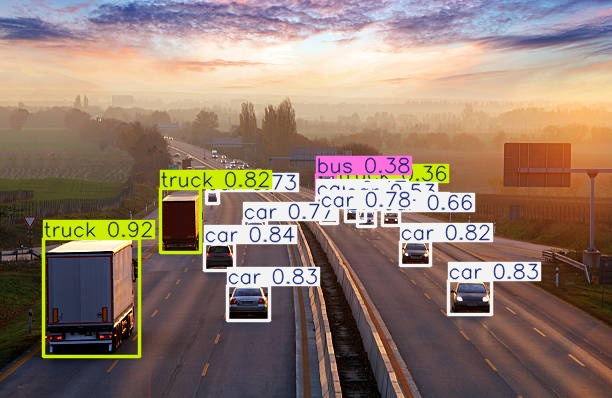

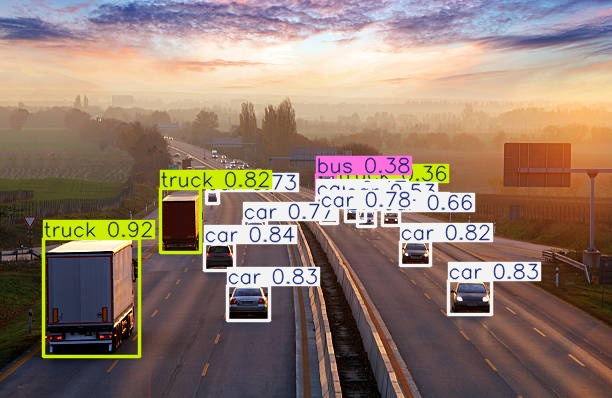

In [ ]:
from google.colab import files
import os
from IPython.display import Image, display

# -------------------------------
# Step 1: Upload the image
# -------------------------------
uploaded = files.upload()  # select your image

# Get uploaded filename
for fname in uploaded.keys():
    file_path = os.path.join("/content", fname)
    print("Uploaded file path:", file_path)

# -------------------------------
# Step 2: Run YOLO / model.predict
# -------------------------------
results = model.predict(
    source=file_path,
    save=True,  # save predictions
    conf=0.2,
    iou=0.5
)

# -------------------------------
# Step 3: Display saved predictions
# -------------------------------
# The predictions are saved in 'runs/detect/predict/'
output_dir = "runs/detect/predict"

# List all files in the output directory
saved_images = sorted(os.listdir(output_dir))
print("Saved prediction images:", saved_images)

# Display all saved images
for img_name in saved_images:
    display(Image(filename=os.path.join(output_dir, img_name)))



In [ ]:
results
#as you can see below, Results object contains 5 components:
# boxes : they are object with properties for manipulating bounding boxes.
# masks : masks object indexing masks or getting segment coordinates
# keypoints : keypoint object for with properties and methods for manipulating predicted keypoints
# probs : pobs object for containing class probabilities
# orig_img : original image loaded in memory
# path :  path to the input image

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [ ]:
result = results[0]

# finding the detailed result(Class, Coordinates, Prob)

for box in result.boxes:
    class_id = result.names[box.cls[0].item()]
    cords = box.xyxy[0].tolist()
    cords = [round(x) for x in cords]
    conf = round(box.conf[0].item(), 2)
    print("Object type:", class_id)
    print("Coordinates:", cords)
    print("Probability:", conf)
    print("---")

Object type: truck
Coordinates: [44, 238, 139, 357]
Probability: 0.92
---
Object type: car
Coordinates: [205, 244, 235, 270]
Probability: 0.84
---
Object type: car
Coordinates: [448, 280, 491, 314]
Probability: 0.83
---
Object type: car
Coordinates: [228, 286, 270, 320]
Probability: 0.83
---
Object type: car
Coordinates: [401, 241, 430, 265]
Probability: 0.82
---
Object type: truck
Coordinates: [161, 189, 201, 252]
Probability: 0.82
---
Object type: car
Coordinates: [321, 208, 337, 223]
Probability: 0.78
---
Object type: car
Coordinates: [244, 221, 267, 238]
Probability: 0.77
---
Object type: car
Coordinates: [207, 191, 219, 203]
Probability: 0.73
---
Object type: car
Coordinates: [382, 211, 400, 226]
Probability: 0.66
---
Object type: car
Coordinates: [357, 210, 376, 227]
Probability: 0.63
---
Object type: car
Coordinates: [345, 200, 366, 221]
Probability: 0.53
---
Object type: car
Coordinates: [317, 197, 329, 208]
Probability: 0.47
---
Object type: bus
Coordinates: [317, 175, 336, 19

Saving img2.jpeg to img2.jpeg
Uploaded file: /content/img2.jpeg

0: 448x640 17 cars, 1 bus, 5 trucks, 50.5ms
Speed: 2.4ms preprocess, 50.5ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict
Prediction for image /content/img2.jpeg:


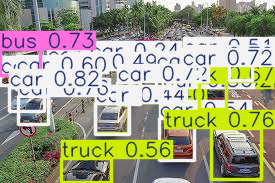

In [ ]:
from google.colab import files
import os
from PIL import Image
from IPython.display import display
import cv2

# -------------------------------
# Step 1: Upload multiple images
# -------------------------------
uploaded = files.upload()  # select one or more images

file_paths = []
for fname in uploaded.keys():
    file_path = os.path.join("/content", fname)
    file_paths.append(file_path)
    print("Uploaded file:", file_path)

# -------------------------------
# Step 2: Run YOLOv8 predictions
# -------------------------------
results = model.predict(
    source=file_paths,  # list of uploaded files
    save=True,          # save predictions
    conf=0.2,
    iou=0.5
)

# -------------------------------
# Step 3: Display predictions using PIL
# -------------------------------
for i, res in enumerate(results):
    res_plotted = res.plot()                          # draw boxes
    res_plotted = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)  # BGR -> RGB
    print(f"Prediction for image {file_paths[i]}:")
    display(Image.fromarray(res_plotted))


In [ ]:
# Install YOLO
!pip install ultralytics --quiet

import cv2
import numpy as np
from ultralytics import YOLO
from google.colab import files
from IPython.display import HTML, display
from base64 import b64encode

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # replace with custom weights if trained

def detect_vehicles_side_by_side(video_path, output_path="vehicles_comparison.mp4"):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Could not open video file.")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Output video will be double width (original + detected side by side)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width * 2, height))

    vehicle_classes = ["car", "bus", "truck", "motorbike"]

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        detected_frame = frame.copy()

        results = model(frame)
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                label = model.names[cls_id]

                if label in vehicle_classes:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    conf = float(box.conf[0])

                    cv2.rectangle(detected_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(detected_frame, f"{label} {conf:.2f}",
                                (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                0.6, (0, 255, 0), 2)

        # Combine original + detected side by side
        combined = np.hstack((frame, detected_frame))
        out.write(combined)

    cap.release()
    out.release()
    print(f"✅ Comparison video saved as {output_path}")
    return output_path


def show_video(video_path, width=800, height=400):
    """Display video inside Colab"""
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""
    <video width={width} height={height} controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)


# --- MAIN WORKFLOW ---
print("📂 Please upload your input video file...")
uploaded = files.upload()

# Get the first uploaded file name
input_video = list(uploaded.keys())[0]
input_path = f"/content/{input_video}"

# Run side-by-side detection
output_path = detect_vehicles_side_by_side(input_path, "vehicles_comparison.mp4")

# Show inside Colab and allow download
if output_path:
    print("▶️ Playing side-by-side video inside Colab...")
    display(show_video(output_path))

    print("⬇️ Downloading video...")
    files.download(output_path)


📂 Please upload your input video file...


Saving cars_video1.mp4 to cars_video1 (1).mp4

0: 384x640 10 cars, 1 bus, 3 trucks, 9.0ms
Speed: 2.4ms preprocess, 9.0ms inference, 7.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 cars, 2 trucks, 9.3ms
Speed: 4.2ms preprocess, 9.3ms inference, 9.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 1 bus, 3 trucks, 12.5ms
Speed: 3.5ms preprocess, 12.5ms inference, 8.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 1 bus, 4 trucks, 8.8ms
Speed: 3.2ms preprocess, 8.8ms inference, 8.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 cars, 3 trucks, 8.6ms
Speed: 3.9ms preprocess, 8.6ms inference, 6.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 cars, 3 trucks, 8.6ms
Speed: 4.6ms preprocess, 8.6ms inference, 6.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 1 bus, 3 trucks, 10.1ms
Speed: 4.0ms preprocess, 10.1ms inference, 10.7ms postprocess per image at shape (1, 3, 384,